Pre-calibration (biased) accuracy: 59.33%
Post-calibration accuracy: 93.00%


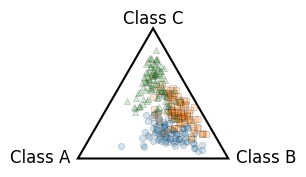

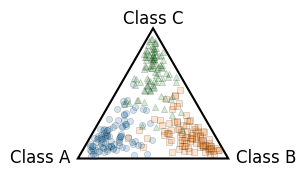

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.special import softmax

# --- Style constants (matching other MCal figures) ---
LABEL_FONTSIZE = 12
TICK_LABELSIZE = 12
LEGEND_FONTSIZE = 12
TIGHT_PAD = 0.5
matplotlib.rcParams['mathtext.fontset'] = 'cm'

def simplex_visualization():
    """
    Generates two separate, professional figures visualizing the effect of MCal 
    on the probability simplex using a principled logit-space simulation.
    """
    # --- 1. Setup and Parameters ---
    num_points_per_class = 100
    vertices = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
    
    # --- 2. Generate Data and Bias in LOGIT SPACE ---

    # Step A: Create clean, well-separated logit clouds
    np.random.seed(42)
    clean_logits_A = np.random.randn(num_points_per_class, 3) * 0.4 + np.array([1, 0, 0])
    clean_logits_B = np.random.randn(num_points_per_class, 3) * 0.4 + np.array([0, 1, 0])
    clean_logits_C = np.random.randn(num_points_per_class, 3) * 0.4 + np.array([0, 0, 1])
    clean_logits = np.vstack([clean_logits_A, clean_logits_B, clean_logits_C])

    # Step B: Create a bias transformation (rotation + shift) to apply to the logits
    angle = np.pi / 2.5 # A significant rotation
    rotation_matrix = np.array([[np.cos(angle), -np.sin(angle), 0],
                                [np.sin(angle),  np.cos(angle), 0],
                                [0, 0, 1]])
    shift = np.array([-2, -2, -2]) # A shift towards the center
    
    # Apply the bias to the clean logits to create the uncalibrated "before" state
    uncalibrated_logits = clean_logits @ rotation_matrix.T + shift
    
    # --- 3. Simulate the "After" Data (Calibrated) ---

    # The ideal calibrator (W, b) learns the inverse transformation + a stretch
    stretch_factor = 1.5 # Stretch to increase confidence
    un_rotation_matrix = np.linalg.inv(rotation_matrix)
    
    # The learned weight matrix W undoes the rotation and applies a stretch
    W = stretch_factor * un_rotation_matrix
    # The learned bias b undoes the shift, adjusted for the stretch
    b = -shift @ W.T
    
    # Apply the learned calibrator to the uncalibrated logits
    calibrated_logits = uncalibrated_logits @ W.T + b
    
    # --- 4. Convert Logits to Probabilities for Plotting ---
    uncalibrated_probs = softmax(uncalibrated_logits, axis=1)
    calibrated_probs = softmax(calibrated_logits, axis=1)

    # --- 5. Calculate Accuracies ---
    true_labels = np.repeat(np.arange(3), num_points_per_class)
    
    pred_labels_before = np.argmax(uncalibrated_probs, axis=1)
    accuracy_before = np.mean(pred_labels_before == true_labels)
    
    pred_labels_after = np.argmax(calibrated_probs, axis=1)
    accuracy_after = np.mean(pred_labels_after == true_labels)
    
    # --- 6. Plotting ---
    # Use matplotlib's default color cycle (tab10)
    prop_cycle = plt.rcParams['axes.prop_cycle']
    default_colors = prop_cycle.by_key()['color']
    palette = default_colors[:3]  # tab:blue, tab:orange, tab:green
    
    # --- Figure 1: Before MCal ---
    fig1, ax1 = plt.subplots(1, 1, figsize=(3, 3))
    plot_simplex_panel(ax1, uncalibrated_probs, vertices, palette, num_points_per_class)
    fig1.tight_layout(pad=TIGHT_PAD)
    fig1.savefig("simplex_before.pdf", bbox_inches='tight')
    
    # --- Figure 2: After MCal ---
    fig2, ax2 = plt.subplots(1, 1, figsize=(3, 3))
    plot_simplex_panel(ax2, calibrated_probs, vertices, palette, num_points_per_class)
    fig2.tight_layout(pad=TIGHT_PAD)
    fig2.savefig("simplex_after.pdf", bbox_inches='tight')
    
    print(f"Pre-calibration (biased) accuracy: {accuracy_before:.2%}")
    print(f"Post-calibration accuracy: {accuracy_after:.2%}")
    
    plt.show()

# --- Helper Functions ---
def plot_simplex_panel(ax, probs, vertices, palette, num_points):
    plot_simplex_boundary(ax, vertices)
    class_data = [probs[i*num_points:(i+1)*num_points, :] for i in range(3)]
    markers = ['o', 's', '^']
    labels = ['Class A', 'Class B', 'Class C']
    
    for i in range(3):
        plot_points(ax, class_data[i], vertices, palette[i], markers[i], labels[i])

def plot_simplex_boundary(ax, vertices):
    triangle = plt.Polygon(vertices, edgecolor='k', facecolor='white', linewidth=1.5, zorder=1)
    ax.add_patch(triangle)
    ax.text(vertices[0, 0] - 0.05, vertices[0, 1] - 0.03, 'Class A', fontsize=LABEL_FONTSIZE, ha='right')
    ax.text(vertices[1, 0] + 0.05, vertices[1, 1] - 0.03, 'Class B', fontsize=LABEL_FONTSIZE, ha='left')
    ax.text(vertices[2, 0], vertices[2, 1] + 0.03, 'Class C', fontsize=LABEL_FONTSIZE, ha='center')
    ax.set_aspect('equal')
    ax.axis('off')

def plot_points(ax, probs, vertices, color, marker, label):
    cartesian_coords = probs @ vertices
    ax.scatter(cartesian_coords[:, 0], cartesian_coords[:, 1], s=20, 
               c=color, marker=marker, label=label, 
               alpha=0.2, edgecolors='k', linewidth=0.5, zorder=2)

# --- Run the visualization ---
if __name__ == '__main__':
    simplex_visualization()
